In [1]:
SEED = 42
import numpy as np
np.random.seed(SEED)
from pathlib import Path
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed/FD001")

X      = np.load(DATA_DIR / "X_train.npy")
y      = np.load(DATA_DIR / "y_train.npy")

print(f"X : {X.shape}")
print(f"y : {y.shape}")


X : (17731, 30, 16)
y : (17731,)


In [2]:
CLASS_LABELS   = {"C0": 0, "C1": 1, "C2": 2, "C3": 3}
CLASS_COLORS   = ["#1D9E75", "#BA7517", "#D85A30", "#E24B4A"]
CLASS_NAMES    = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]

# op3 dropped (constant in FD001), 16 features now
FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]

MONOTONE_INCREASING = ["s4"]
MONOTONE_DECREASING = ["s3", "s7", "s11"]

In [3]:
def assign_fault_class(rul: float) -> int:
    if rul > 100:
        return 0   # C0
    elif rul > 50:
        return 1   # C1
    elif rul > 10:
        return 2   # C2
    else:
        return 3   # C3

labels = np.vectorize(assign_fault_class)(y).astype(np.int64)
np.save(DATA_DIR / "labels_train.npy", labels)
print("labels_train.npy saved")
print(f"unique classes : {np.unique(labels)}")


labels_train.npy saved
unique classes : [0 1 2 3]


In [4]:
unique, counts = np.unique(labels, return_counts=True)
dist = pd.DataFrame({
    "class_id"  : unique,
    "class_name": [list(CLASS_LABELS.keys())[i] for i in unique],
    "count"     : counts,
    "pct"       : counts / counts.sum() * 100,
})
print(dist.to_string(index=False))
dist.to_csv(DATA_DIR / "class_distribution.csv", index=False)
print("\nclass_distribution.csv saved")


 class_id class_name  count       pct
        0         C0   7633 43.048897
        1         C1   4998 28.187919
        2         C2   4000 22.559359
        3         C3   1100  6.203824

class_distribution.csv saved


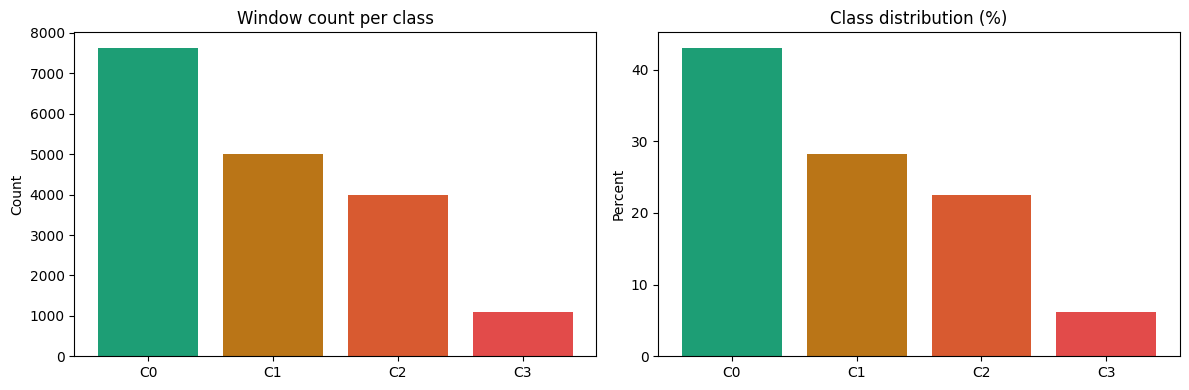

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(dist["class_name"], dist["count"], color=CLASS_COLORS)
axes[0].set_title("Window count per class")
axes[0].set_ylabel("Count")

axes[1].bar(dist["class_name"], dist["pct"], color=CLASS_COLORS)
axes[1].set_title("Class distribution (%)")
axes[1].set_ylabel("Percent")

plt.tight_layout()
plt.savefig("../reports/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
X_mean = X.mean(axis=1)   # (N, 14) - mean over time axis

results = []
for sensor in MONOTONE_INCREASING + MONOTONE_DECREASING:
    if sensor not in FEATURE_COLS:
        continue
    idx       = FEATURE_COLS.index(sensor)
    direction = "increase" if sensor in MONOTONE_INCREASING else "decrease"
    class_means = []
    for c in range(4):
        mask = labels == c
        val  = X_mean[mask, idx].mean() if mask.sum() > 0 else np.nan
        class_means.append(val)

    valid = [m for m in class_means if not np.isnan(m)]
    if direction == "increase":
        holds = all(valid[i] <= valid[i+1] for i in range(len(valid)-1))
    else:
        holds = all(valid[i] >= valid[i+1] for i in range(len(valid)-1))

    results.append({
        "sensor"        : sensor,
        "direction"     : direction,
        "C0_mean"       : class_means[0],
        "C1_mean"       : class_means[1],
        "C2_mean"       : class_means[2],
        "C3_mean"       : class_means[3],
        "monotone_holds": holds,
    })

mono_df = pd.DataFrame(results)
print(mono_df.to_string(index=False))
print(f"\nAll checks pass: {mono_df['monotone_holds'].all()}")


sensor direction  C0_mean  C1_mean  C2_mean  C3_mean  monotone_holds
    s4  increase 0.255647 0.344362 0.503520 0.672125            True
    s3  decrease 0.356773 0.403533 0.491060 0.580945           False
    s7  decrease 0.727569 0.645971 0.489163 0.323651            True
   s11  decrease 0.234722 0.321059 0.489225 0.672159           False

All checks pass: False


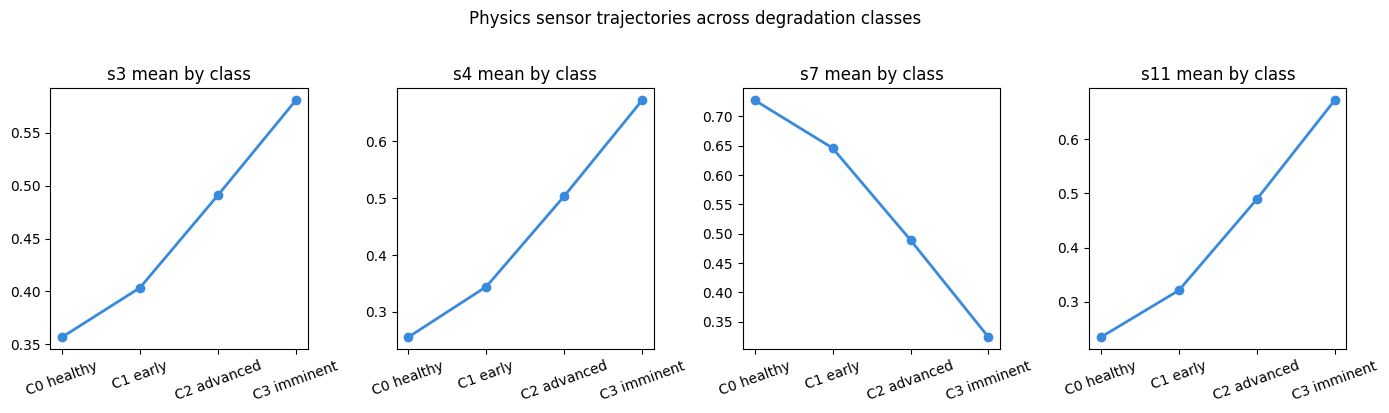

In [7]:
sensors_to_plot = ["s3", "s4", "s7", "s11"]

fig, axes = plt.subplots(1, len(sensors_to_plot), figsize=(14, 4))
for ax, sensor in zip(axes, sensors_to_plot):
    idx   = FEATURE_COLS.index(sensor)
    means = [X_mean[labels == c, idx].mean() for c in range(4)]
    ax.plot(CLASS_NAMES, means, marker="o", color="#378ADD", linewidth=2)
    ax.set_title(f"{sensor} mean by class")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Physics sensor trajectories across degradation classes", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/sensor_monotonicity.png", dpi=150, bbox_inches="tight")
plt.show()


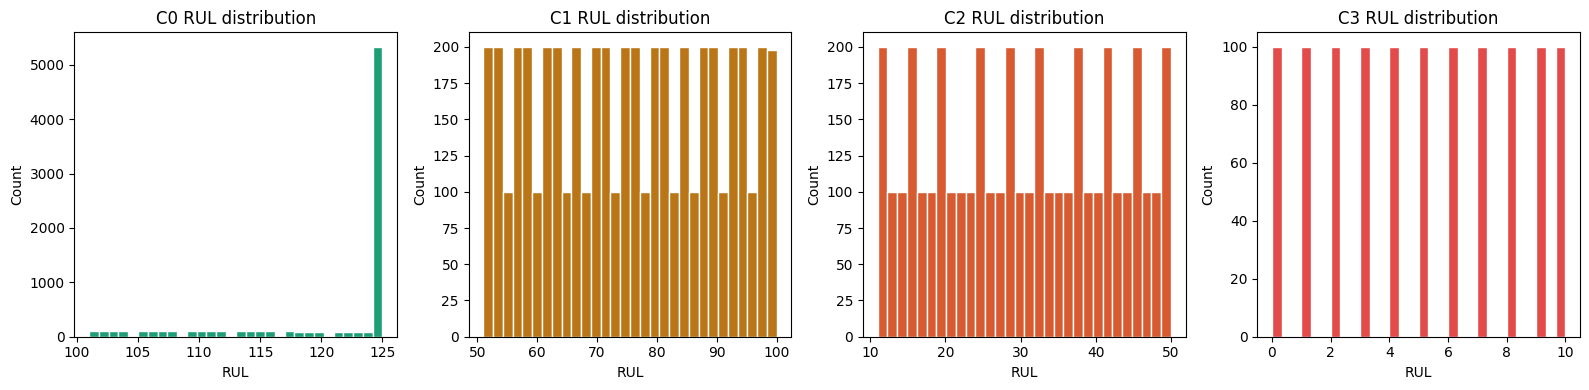

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for c, ax in enumerate(axes):
    ax.hist(y[labels == c], bins=30, color=CLASS_COLORS[c], edgecolor="white")
    ax.set_title(f"C{c} RUL distribution")
    ax.set_xlabel("RUL")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/rul_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
c0_count = dist.loc[dist["class_id"] == 0, "count"].values[0]
c3_count = dist.loc[dist["class_id"] == 3, "count"].values[0]

print(f"C0 / C3 imbalance ratio : {c0_count / c3_count:.1f}x")
print("C2 and C3 will be oversampled during Phase 6 (GAN generation).")


C0 / C3 imbalance ratio : 6.9x
C2 and C3 will be oversampled during Phase 6 (GAN generation).
